# Book Review Rating Prediction (1-5)


In [ ]:
# Install required libraries
# In Colab, run this cell first. Restart runtime only if prompted.

!pip install -q gensim gradio wordcloud nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.7 MB/s eta 0:00:00


In [ ]:
# Core imports
import os
import re
import time
import pickle
import random
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

# NLP
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model

# Pretrained embeddings
import gensim.downloader as api

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Main configuration

DATA_PATH = "/content/drive/MyDrive/Artificial Intelligence/BookReviewDataset/Book_review.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

print("Dataset found:", DATA_PATH)

SAVE_DIR = "saved_rating_models_sandil"
os.makedirs(SAVE_DIR, exist_ok=True)

VOCAB_SIZE = 20000
EMBED_DIM = 100
BATCH_SIZE = 64

# Reduced-regularization training setup
EPOCHS_ABLATION = 20
EPOCHS_MAIN = 20

# Keep class weighting off by default. The dataset imbalance is mild, and using
# class weights made the previous recurrent models unstable.
TRAIN_WITH_CLASS_WEIGHTS = False

OOV_TOKEN = "<OOV>"

Dataset found: /content/drive/MyDrive/Artificial Intelligence/BookReviewDataset/Book_review.csv


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Keep recurrent_dropout at zero so TensorFlow can use the faster GPU/cuDNN path.
RECURRENT_DROPOUT = 0.0

# A normal Adam learning rate helps the model learn faster than the previous 3e-4 setup.
LEARNING_RATE = 1e-3

## Load and inspect the dataset

In [ ]:
df = pd.read_csv(DATA_PATH)

# Drop unnamed index columns if present
df = df.drop(columns=[col for col in df.columns if col.lower().startswith("unnamed")], errors="ignore")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
print("\nMissing values:")
print(df.isna().sum())

Shape: (12000, 3)
Columns: ['rating', 'reviewText', 'summary']


,rating,reviewText,summary
0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,5,"This isn't the kind of book I normally read, a...",Great Story!



Missing values:
rating        0
reviewText    0
summary       2
dtype: int64


Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


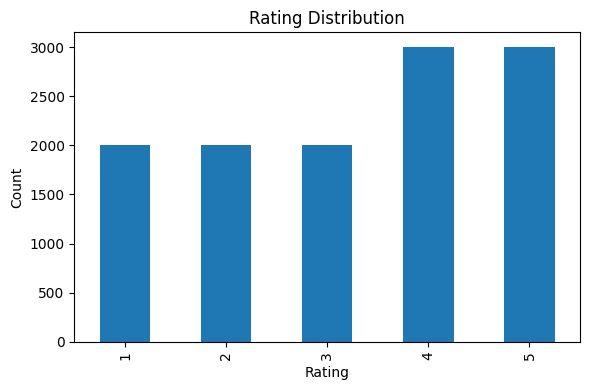

In [ ]:
# Keep required columns only
required_cols = ["rating", "reviewText"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Required column missing: {col}")

# summary is optional but expected in this dataset
if "summary" not in df.columns:
    df["summary"] = ""

df["reviewText"] = df["reviewText"].fillna("")
df["summary"] = df["summary"].fillna("")
df = df.dropna(subset=["rating"])

# Ensure rating is integer 1-5
df["rating"] = df["rating"].astype(int)

print("Rating distribution:")
print(df["rating"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Text preprocessing



In [ ]:
CONTRACTIONS = {
    # Standard apostrophe contractions
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "couldn't": "could not",
    "shouldn't": "should not", "can't": "cannot",
    "wasn't": "was not", "weren't": "were not",
    "hasn't": "has not", "haven't": "have not", "hadn't": "had not",
    "isn't": "is not", "aren't": "are not",

    # Common non-negative contractions
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "it'll": "it will", "that's": "that is",
    "there's": "there is", "they're": "they are", "they've": "they have",
    "they'll": "they will", "they'd": "they would",
    "we're": "we are", "we've": "we have", "we'll": "we will", "we'd": "we would",
    "you're": "you are", "you've": "you have", "you'll": "you will", "you'd": "you would",
    "he's": "he is", "she's": "she is", "he'll": "he will", "she'll": "she will",
    "what's": "what is", "who's": "who is", "where's": "where is", "let's": "let us",

    # Safer missing-apostrophe forms
    "dont": "do not", "doesnt": "does not", "didnt": "did not",
    "wont": "will not", "wouldnt": "would not", "couldnt": "could not",
    "shouldnt": "should not", "cant": "cannot",
    "wasnt": "was not", "werent": "were not",
    "hasnt": "has not", "havent": "have not", "hadnt": "had not",
    "isnt": "is not", "arent": "are not"
}

def expand_contractions(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.replace("’", "'").replace("‘", "'")
    for contraction, expansion in CONTRACTIONS.items():
        pattern = r"\b" + re.escape(contraction) + r"\b"
        text = re.sub(pattern, expansion, text)
    return text

lemmatizer = WordNetLemmatizer()

# Preserve negation words because they are important for rating/sentiment meaning. Short words such as "no" must not be removed.
NEGATION_WORDS = {"no", "not", "nor", "never", "none", "nobody", "nothing", "neither", "nowhere", "cannot"}
stop_words = set(stopwords.words("english")) - NEGATION_WORDS

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = expand_contractions(text)

    # Remove URLs, mentions, hashtags, numbers
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)

    # Keep letters and whitespace only
    text = re.sub(r"[^a-z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and (len(token) > 1 or token in NEGATION_WORDS)
    ]

    return " ".join(tokens)

In [ ]:
# Create two candidate text inputs:
# 1. reviewText only
# 2. summary + reviewText

df["text_review_only"] = df["reviewText"].fillna("")
df["text_combined"] = df["summary"].fillna("") + " " + df["reviewText"].fillna("")

df["clean_review_only"] = df["text_review_only"].apply(clean_text)
df["clean_combined"] = df["text_combined"].apply(clean_text)

display(df[["rating", "summary", "reviewText", "clean_review_only", "clean_combined"]].head(3))

,rating,summary,reviewText,clean_review_only,clean_combined
0,5,50 + years ago...,This book was the very first bookmobile book I...,book first bookmobile book bought school book ...,year ago book first bookmobile book bought sch...
1,1,Boring! Boring! Boring!,"When I read the description for this book, I c...",read description book could not wait read down...,boring boring boring read description book cou...
2,5,Wiggleliscious/new toy ready/!!,I just had to edit this review. This book is a...,edit review book believe got right updated wri...,wiggleliscious new toy ready edit review book ...


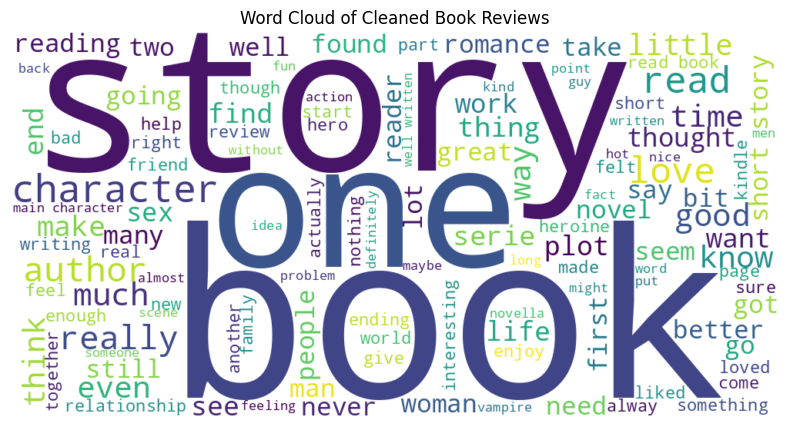

,word,count
0,not,20146
1,book,16616
2,story,12355
3,read,9246
4,one,6392
5,character,5943
6,like,5424
7,good,5423
8,would,5128
9,love,4230


In [ ]:
# Quick word cloud for combined cleaned text
all_text = " ".join(df["clean_combined"].astype(str).tolist())

plt.figure(figsize=(10, 5))
wc = WordCloud(width=1000, height=500, background_color="white", max_words=120).generate(all_text)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Book Reviews")
plt.show()

# Most frequent words
word_counts = Counter(all_text.split())
common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
display(common_words)

## Encode target labels using LabelEncoder


In [ ]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["rating"])

class_names = [str(c) for c in label_encoder.classes_]
NUM_CLASSES = len(class_names)

print("Label mapping:")
for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"Rating {original} -> class index {encoded}")

print("Number of classes:", NUM_CLASSES)

Label mapping:
Rating 1 -> class index 0
Rating 2 -> class index 1
Rating 3 -> class index 2
Rating 4 -> class index 3
Rating 5 -> class index 4
Number of classes: 5


## Train/validation/test split
- 80% training
- 10% validation
- 10% test


In [ ]:
# Split indices once so both text variants use exactly the same rows.
indices = np.arange(len(df))
y = df["label"].values

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

print("\nTrain distribution:", Counter(y_train))
print("Validation distribution:", Counter(y_val))
print("Test distribution:", Counter(y_test))

Train size: 9600
Validation size: 1200
Test size: 1200

Train distribution: Counter({np.int64(3): 2400, np.int64(4): 2400, np.int64(2): 1600, np.int64(1): 1600, np.int64(0): 1600})
Validation distribution: Counter({np.int64(3): 300, np.int64(4): 300, np.int64(0): 200, np.int64(2): 200, np.int64(1): 200})
Test distribution: Counter({np.int64(3): 300, np.int64(4): 300, np.int64(2): 200, np.int64(1): 200, np.int64(0): 200})


## Helper functions for tokenization, callbacks, evaluation, and plotting

In [ ]:
def prepare_sequences(text_series, train_idx, val_idx, test_idx, vocab_size=VOCAB_SIZE):
    X_train_text = text_series.iloc[train_idx].astype(str).tolist()
    X_val_text   = text_series.iloc[val_idx].astype(str).tolist()
    X_test_text  = text_series.iloc[test_idx].astype(str).tolist()

    tokenizer = Tokenizer(num_words=vocab_size, oov_token=OOV_TOKEN)
    tokenizer.fit_on_texts(X_train_text)

    train_seq = tokenizer.texts_to_sequences(X_train_text)
    val_seq   = tokenizer.texts_to_sequences(X_val_text)
    test_seq  = tokenizer.texts_to_sequences(X_test_text)

    # Percentile-based padding avoids using an extreme maximum review length.
    train_lengths = [len(seq) for seq in train_seq]
    max_len = int(np.percentile(train_lengths, 95))
    max_len = max(max_len, 10)

    X_train_pad = pad_sequences(train_seq, maxlen=max_len, padding="post", truncating="post")
    X_val_pad   = pad_sequences(val_seq,   maxlen=max_len, padding="post", truncating="post")
    X_test_pad  = pad_sequences(test_seq,  maxlen=max_len, padding="post", truncating="post")

    actual_vocab_size = min(vocab_size, len(tokenizer.word_index) + 1)

    return tokenizer, max_len, actual_vocab_size, X_train_pad, X_val_pad, X_test_pad


def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            # Moderate patience: enough time to learn, but still prevents long overfitting.
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(SAVE_DIR, f"best_{model_name}.keras"),
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        )
    ]


def evaluate_model(model, X_test_pad, y_test, model_name):
    from sklearn.metrics import precision_recall_fscore_support
    pred_probs = model.predict(X_test_pad, verbose=0)
    y_pred     = np.argmax(pred_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    print(f"\n{model_name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}  (macro)")
    print(f"Recall    : {recall:.4f}  (macro)")
    print(f"Macro F1  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "model":         model_name,
        "accuracy":      acc,
        "macro_f1":      f1,
        "y_pred":        y_pred,
        "pred_probs":    pred_probs
    }


def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(hist["loss"],     label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["accuracy"],     label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.tight_layout(); plt.show()


In [ ]:
# Class weights are computed for reference only.
# They are not used by default because the rating imbalance is mild and the
# previous model became unstable when class weights were applied to every RNN/LSTM.
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
fit_class_weight = class_weight_dict if TRAIN_WITH_CLASS_WEIGHTS else None

print("Class weights:", class_weight_dict)
print("Using class weights during neural training:", TRAIN_WITH_CLASS_WEIGHTS)

Class weights: {np.int64(0): np.float64(1.2), np.int64(1): np.float64(1.2), np.int64(2): np.float64(1.2), np.int64(3): np.float64(0.8), np.int64(4): np.float64(0.8)}
Using class weights during neural training: False


## 6. Ablation Study: reviewText only vs summary + reviewText


In [ ]:
def build_ablation_lstm(vocab_size, max_len):
    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
        layers.Bidirectional(layers.LSTM(48, dropout=0.15, recurrent_dropout=RECURRENT_DROPOUT)),
        layers.Dropout(0.25),
        layers.Dense(48, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="ablation_bilstm_reduced_regularization")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

ablation_results = []

for variant_name, col in [
    ("review_only",        "clean_review_only"),
    ("summary_plus_review","clean_combined")
]:
    print(f"\n===== Ablation variant: {variant_name} =====")
    tokenizer_tmp, max_len_tmp, vocab_tmp, X_train_tmp, X_val_tmp, X_test_tmp = prepare_sequences(
        df[col], train_idx, val_idx, test_idx
    )

    model_tmp = build_ablation_lstm(vocab_tmp, max_len_tmp)

    start = time.time()
    history_tmp = model_tmp.fit(
        X_train_tmp, y_train,
        validation_data=(X_val_tmp, y_val),
        epochs=EPOCHS_ABLATION,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(f"ablation_{variant_name}"),
        class_weight=fit_class_weight,
        verbose=1
    )
    train_time = time.time() - start

    val_probs = model_tmp.predict(X_val_tmp, verbose=0)
    val_pred  = np.argmax(val_probs, axis=1)
    val_acc   = accuracy_score(y_val, val_pred)

    from sklearn.metrics import precision_recall_fscore_support
    _, _, val_f1, _ = precision_recall_fscore_support(y_val, val_pred, average="macro", zero_division=0)

    ablation_results.append({
        "variant":       variant_name,
        "text_column":   col,
        "val_accuracy":  val_acc,
        "val_macro_f1":  val_f1,
        "max_len":       max_len_tmp,
        "vocab_size":    vocab_tmp,
        "train_time_sec":train_time
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("val_macro_f1", ascending=False)
display(ablation_df)

BEST_TEXT_COL = ablation_df.iloc[0]["text_column"]
BEST_VARIANT  = ablation_df.iloc[0]["variant"]
print(f"\nSelected text variant: {BEST_VARIANT} ({BEST_TEXT_COL})")


===== Ablation variant: review_only =====
Epoch 1/20
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2787 - loss: 1.5534
Epoch 1: val_loss improved from None to 1.28138, saving model to saved_rating_models_sandil/best_ablation_review_only.keras

Epoch 1: finished saving model to saved_rating_models_sandil/best_ablation_review_only.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.3239 - loss: 1.4586 - val_accuracy: 0.3933 - val_loss: 1.2814 - learning_rate: 0.0010
Epoch 2/20
147/150 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4360 - loss: 1.2121
Epoch 2: val_loss improved from 1.28138 to 1.19622, saving model to saved_rating_models_sandil/best_ablation_review_only.keras

Epoch 2: finished saving model to saved_rating_models_sandil/best_ablation_review_only.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4592 - loss: 1.1549 - val_accuracy: 0.4725 - val_loss: 1.1962 - learning_rate: 0.0010
Epoch 3/20
147/150 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accu

,variant,text_column,val_accuracy,val_macro_f1,max_len,vocab_size,train_time_sec
1,summary_plus_review,clean_combined,0.496667,0.477627,190,20000,24.899245
0,review_only,clean_review_only,0.472500,0.454468,186,20000,31.382633



Selected text variant: summary_plus_review (clean_combined)


## 7. Prepare final text sequences using the selected text variant

In [ ]:
tokenizer, MAX_LEN, ACTUAL_VOCAB_SIZE, X_train_pad, X_val_pad, X_test_pad = prepare_sequences(
    df[BEST_TEXT_COL], train_idx, val_idx, test_idx
)

print("Selected text column:", BEST_TEXT_COL)
print("MAX_LEN:", MAX_LEN)
print("Actual vocab size:", ACTUAL_VOCAB_SIZE)
print("X_train_pad:", X_train_pad.shape)
print("X_val_pad:", X_val_pad.shape)
print("X_test_pad:", X_test_pad.shape)

Selected text column: clean_combined
MAX_LEN: 190
Actual vocab size: 20000
X_train_pad: (9600, 190)
X_val_pad: (1200, 190)
X_test_pad: (1200, 190)


## Baseline: TF-IDF + Logistic Regression


TF-IDF + Logistic Regression
Accuracy  : 0.5583
Precision : 0.5580  (macro)
Recall    : 0.5430  (macro)
Macro F1  : 0.5429

Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.69      0.68       200
           2       0.55      0.48      0.51       200
           3       0.49      0.28      0.36       200
           4       0.48      0.58      0.52       300
           5       0.60      0.69      0.64       300

    accuracy                           0.56      1200
   macro avg       0.56      0.54      0.54      1200
weighted avg       0.56      0.56      0.55      1200



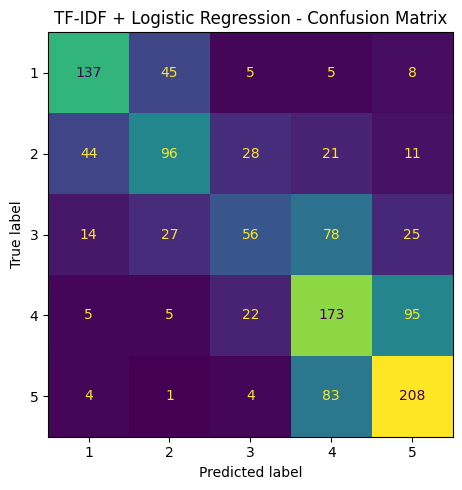

In [ ]:
# TF-IDF + Logistic Regression baseline
X_train_text = df[BEST_TEXT_COL].iloc[train_idx].astype(str)
X_val_text   = df[BEST_TEXT_COL].iloc[val_idx].astype(str)
X_test_text  = df[BEST_TEXT_COL].iloc[test_idx].astype(str)

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_text)

start = time.time()
tfidf_lr_model = LogisticRegression(
    max_iter=1000,
    class_weight=None,
    random_state=SEED,
    n_jobs=-1
)
tfidf_lr_model.fit(X_train_tfidf, y_train)
tfidf_time = time.time() - start

y_pred_tfidf = tfidf_lr_model.predict(X_test_tfidf)

from sklearn.metrics import precision_recall_fscore_support
tfidf_acc = accuracy_score(y_test, y_pred_tfidf)
tfidf_precision, tfidf_recall, tfidf_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_tfidf, average="macro", zero_division=0
)

print("TF-IDF + Logistic Regression")
print(f"Accuracy  : {tfidf_acc:.4f}")
print(f"Precision : {tfidf_precision:.4f}  (macro)")
print(f"Recall    : {tfidf_recall:.4f}  (macro)")
print(f"Macro F1  : {tfidf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=class_names, zero_division=0))

tfidf_result = {
    "model": "TF-IDF + Logistic Regression",
    "accuracy": tfidf_acc,
    "precision_macro": tfidf_precision,
    "recall_macro": tfidf_recall,
    "macro_f1": tfidf_f1,
    "training_time_sec": tfidf_time,
    "parameters": np.nan,
    "y_pred": y_pred_tfidf,
    "pred_probs": tfidf_lr_model.predict_proba(X_test_tfidf)
}

cm = confusion_matrix(y_test, y_pred_tfidf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
plt.title("TF-IDF + Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 9. Model 1: Simple RNN with trainable embedding

BatchNormalization and L2 are used because they are imported and they provide regularization/stabilization.

In [ ]:
def build_rnn_model(vocab_size, max_len, embed_dim=EMBED_DIM):
    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        layers.SimpleRNN(64, dropout=0.15, recurrent_dropout=RECURRENT_DROPOUT),
        layers.Dropout(0.25),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="rnn_rating_model_reduced_regularization")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

rnn_model = build_rnn_model(ACTUAL_VOCAB_SIZE, MAX_LEN)
rnn_model.summary()

Model: "rnn_rating_model_reduced_regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2484 - loss: 1.6037
Epoch 1: val_loss improved from None to 1.61138, saving model to saved_rating_models_sandil/best_rnn_model.keras

Epoch 1: finished saving model to saved_rating_models_sandil/best_rnn_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.2448 - loss: 1.6130 - val_accuracy: 0.2192 - val_loss: 1.6114 - learning_rate: 0.0010
Epoch 2/20
147/150 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2409 - loss: 1.6208
Epoch 2: val_loss improved from 1.61138 to 1.60318, saving model to saved_rating_models_sandil/best_rnn_model.keras

Epoch 2: finished saving model to saved_rating_models_sandil/best_rnn_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2415 - loss: 1.6182 - val_accuracy: 0.2242 - val_loss: 1.6032 - learning_rate: 0.0010
Epoch 3/20
147/150 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2292 - loss: 1.6105
Epoch 3: val_loss improved from 1.60318 to 1.59787, saving m

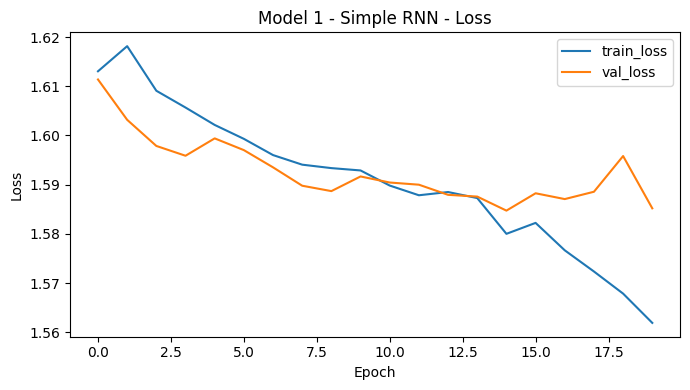

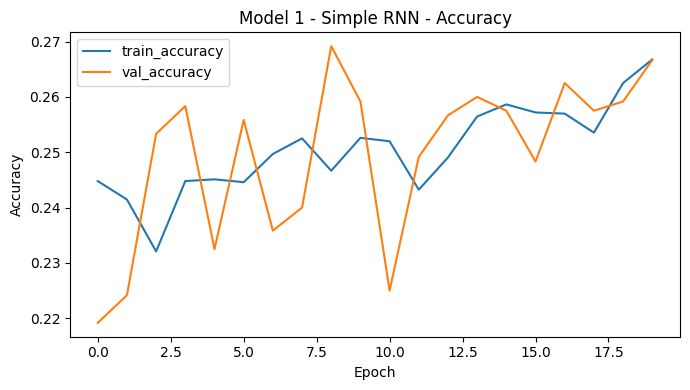


Model 1 - Simple RNN
Accuracy  : 0.2475
Precision : 0.0997  (macro)
Recall    : 0.1980  (macro)
Macro F1  : 0.1316

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       200
           2       0.00      0.00      0.00       200
           3       0.00      0.00      0.00       200
           4       0.24      0.57      0.34       300
           5       0.26      0.42      0.32       300

    accuracy                           0.25      1200
   macro avg       0.10      0.20      0.13      1200
weighted avg       0.12      0.25      0.16      1200



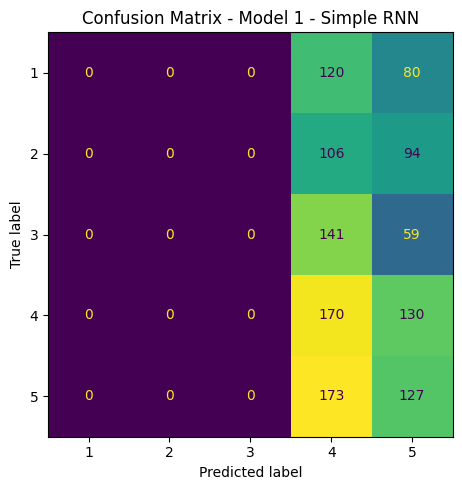

In [ ]:
start = time.time()
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS_MAIN,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("rnn_model"),
    class_weight=fit_class_weight,
    verbose=1
)
rnn_time = time.time() - start

plot_history(history_rnn, "Model 1 - Simple RNN")
rnn_result = evaluate_model(rnn_model, X_test_pad, y_test, "Model 1 - Simple RNN")
rnn_result["training_time_sec"] = rnn_time
rnn_result["parameters"] = rnn_model.count_params()

##LSTM with trainable embedding

In [ ]:
def build_lstm_model(vocab_size, max_len, embed_dim=EMBED_DIM):
    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        layers.Bidirectional(layers.LSTM(64, dropout=0.15, recurrent_dropout=RECURRENT_DROPOUT)),
        layers.Dropout(0.30),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="bilstm_rating_model_reduced_regularization")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm_model(ACTUAL_VOCAB_SIZE, MAX_LEN)
lstm_model.summary()

Model: "bilstm_rating_model_reduced_regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2895 - loss: 1.5237
Epoch 1: val_loss improved from None to 1.17155, saving model to saved_rating_models_sandil/best_lstm_model.keras

Epoch 1: finished saving model to saved_rating_models_sandil/best_lstm_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.3596 - loss: 1.3928 - val_accuracy: 0.4858 - val_loss: 1.1715 - learning_rate: 0.0010
Epoch 2/20
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5307 - loss: 1.0712
Epoch 2: val_loss improved from 1.17155 to 1.15191, saving model to saved_rating_models_sandil/best_lstm_model.keras

Epoch 2: finished saving model to saved_rating_models_sandil/best_lstm_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5592 - loss: 1.0053 - val_accuracy: 0.4900 - val_loss: 1.1519 - learning_rate: 0.0010
Epoch 3/20
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6604 - loss: 0.8334
Epoch 3: val_loss did not improve from 1.15191
150/150 ━

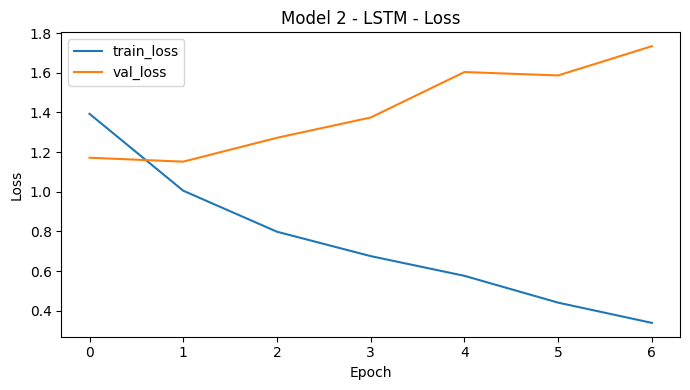

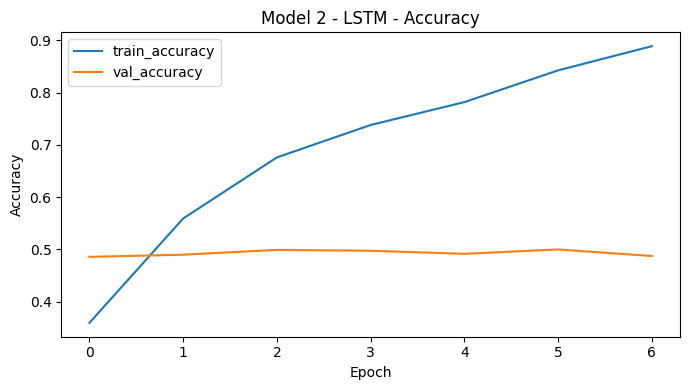


Model 2 - LSTM
Accuracy  : 0.4933
Precision : 0.4858  (macro)
Recall    : 0.4910  (macro)
Macro F1  : 0.4832

Classification Report:
              precision    recall  f1-score   support

           1       0.53      0.70      0.61       200
           2       0.36      0.30      0.33       200
           3       0.39      0.43      0.41       200
           4       0.48      0.50      0.49       300
           5       0.67      0.51      0.58       300

    accuracy                           0.49      1200
   macro avg       0.49      0.49      0.48      1200
weighted avg       0.50      0.49      0.49      1200



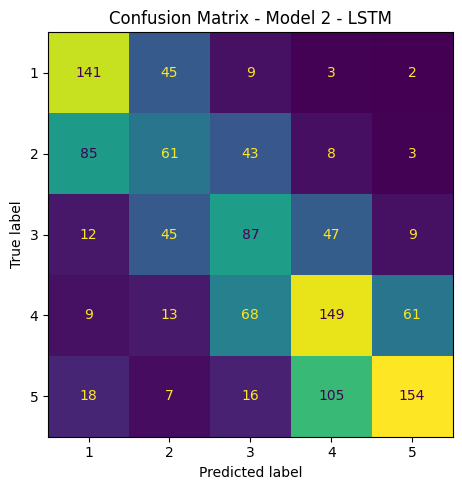

In [ ]:
start = time.time()
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS_MAIN,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm_model"),
    class_weight=fit_class_weight,
    verbose=1
)
lstm_time = time.time() - start

plot_history(history_lstm, "Model 2 - LSTM")
lstm_result = evaluate_model(lstm_model, X_test_pad, y_test, "Model 2 - LSTM")
lstm_result["training_time_sec"] = lstm_time
lstm_result["parameters"] = lstm_model.count_params()

## LSTM with pretrained GloVe embeddings


In [ ]:
print("Loading pretrained GloVe embeddings. This may take a few minutes the first time...")
embedding_model = api.load("glove-wiki-gigaword-100")
GLOVE_DIM = 100
print("Loaded GloVe model.")

Loading pretrained GloVe embeddings. This may take a few minutes the first time...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded GloVe model.


In [ ]:
embedding_matrix = np.zeros((ACTUAL_VOCAB_SIZE, GLOVE_DIM), dtype=np.float32)

found_words = 0
for word, idx in tokenizer.word_index.items():
    if idx >= ACTUAL_VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found_words += 1

coverage = found_words / max(1, ACTUAL_VOCAB_SIZE - 1)
print(f"Embedding coverage: {found_words}/{ACTUAL_VOCAB_SIZE - 1} = {coverage:.2%}")

Embedding coverage: 17860/19999 = 89.30%


In [ ]:
def build_glove_lstm_model(vocab_size, max_len, embedding_matrix):
    model = keras.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_matrix.shape[1],
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=True   # fine-tune GloVe instead of keeping it frozen
        ),
        layers.Bidirectional(layers.LSTM(64, dropout=0.15, recurrent_dropout=RECURRENT_DROPOUT)),
        layers.Dropout(0.30),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="glove_bilstm_rating_model_reduced_regularization")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

glove_lstm_model = build_glove_lstm_model(ACTUAL_VOCAB_SIZE, MAX_LEN, embedding_matrix)
glove_lstm_model.summary()

Model: "glove_bilstm_rating_model_reduced_regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2960 - loss: 1.5235
Epoch 1: val_loss improved from None to 1.23342, saving model to saved_rating_models_sandil/best_glove_lstm_model.keras

Epoch 1: finished saving model to saved_rating_models_sandil/best_glove_lstm_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.3528 - loss: 1.4285 - val_accuracy: 0.4383 - val_loss: 1.2334 - learning_rate: 0.0010
Epoch 2/20
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4534 - loss: 1.2449
Epoch 2: val_loss improved from 1.23342 to 1.15464, saving model to saved_rating_models_sandil/best_glove_lstm_model.keras

Epoch 2: finished saving model to saved_rating_models_sandil/best_glove_lstm_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4680 - loss: 1.1984 - val_accuracy: 0.4758 - val_loss: 1.1546 - learning_rate: 0.0010
Epoch 3/20
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5144 - loss: 1.1079
Epoch 3: val_loss improved from 

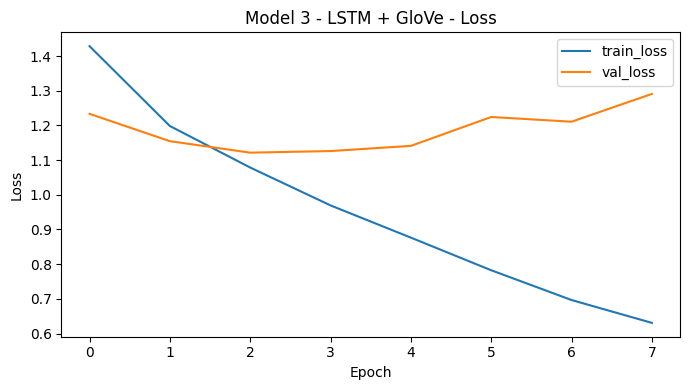

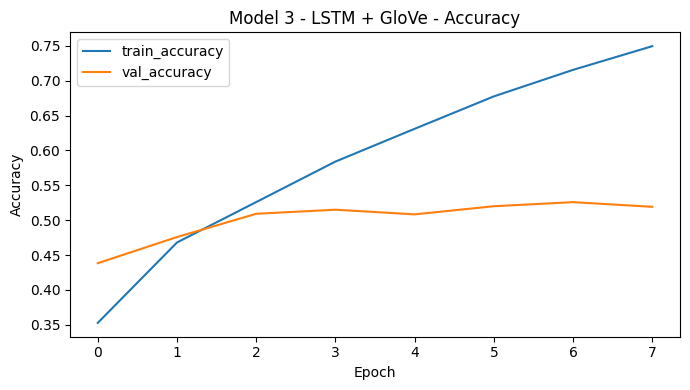


Model 3 - LSTM + GloVe
Accuracy  : 0.5025
Precision : 0.4930  (macro)
Recall    : 0.4983  (macro)
Macro F1  : 0.4934

Classification Report:
              precision    recall  f1-score   support

           1       0.59      0.71      0.65       200
           2       0.38      0.40      0.39       200
           3       0.36      0.34      0.35       200
           4       0.46      0.48      0.47       300
           5       0.67      0.57      0.61       300

    accuracy                           0.50      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.51      0.50      0.50      1200



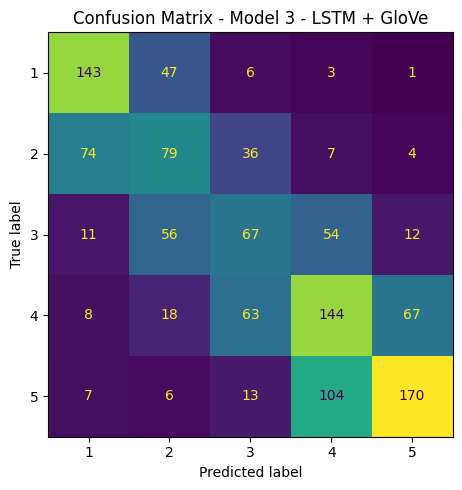

In [ ]:
start = time.time()
history_glove = glove_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS_MAIN,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("glove_lstm_model"),
    class_weight=fit_class_weight,
    verbose=1
)
glove_time = time.time() - start

plot_history(history_glove, "Model 3 - LSTM + GloVe")
glove_result = evaluate_model(glove_lstm_model, X_test_pad, y_test, "Model 3 - LSTM + GloVe")
glove_result["training_time_sec"] = glove_time
glove_result["parameters"] = glove_lstm_model.count_params()

## Compare all models

,model,accuracy,precision_macro,recall_macro,macro_f1,training_time_sec,parameters
0,TF-IDF + Logistic Regression,0.558333,0.558046,0.543,0.542870,4.225445,NaN
3,Model 3 - LSTM + GloVe,0.502500,NaN,NaN,0.493424,30.177604,2093061.0
2,Model 2 - LSTM,0.493333,NaN,NaN,0.483160,26.241176,2093061.0
1,Model 1 - Simple RNN,0.247500,NaN,NaN,0.131631,60.928083,2015045.0


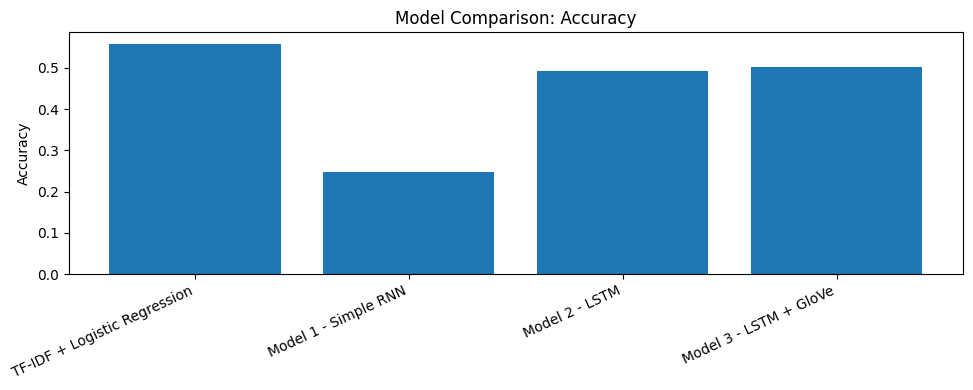

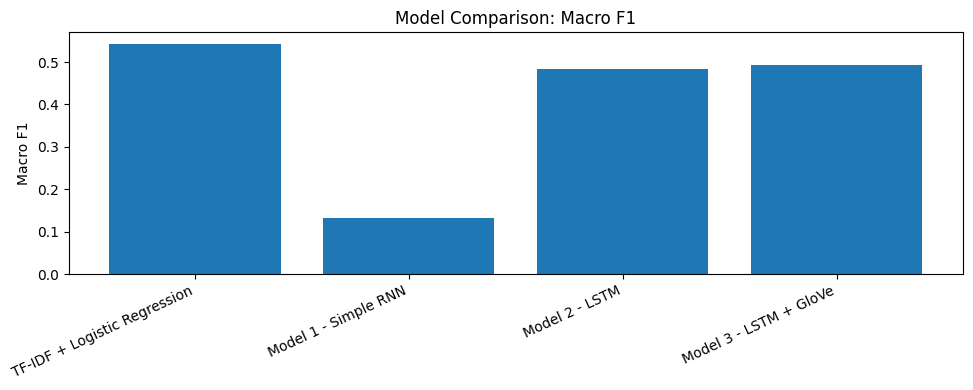

In [ ]:
comparison = pd.DataFrame([
    {k: v for k, v in tfidf_result.items() if k not in ["y_pred", "pred_probs"]},
    {k: v for k, v in rnn_result.items()   if k not in ["y_pred", "pred_probs"]},
    {k: v for k, v in lstm_result.items()  if k not in ["y_pred", "pred_probs"]},
    {k: v for k, v in glove_result.items() if k not in ["y_pred", "pred_probs"]}
])

display(comparison.sort_values("macro_f1", ascending=False))

plt.figure(figsize=(10, 4))
plt.bar(comparison["model"], comparison["accuracy"])
plt.title("Model Comparison: Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(comparison["model"], comparison["macro_f1"])
plt.title("Model Comparison: Macro F1")
plt.ylabel("Macro F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Error analysis


In [ ]:
best_row = comparison.sort_values("macro_f1", ascending=False).iloc[0]
best_model_name = best_row["model"]

if "TF-IDF" in best_model_name:
    best_model = tfidf_lr_model
    best_result = tfidf_result
    best_model_type = "tfidf_logistic_regression"
elif "GloVe" in best_model_name:
    best_model = glove_lstm_model
    best_result = glove_result
    best_model_type = "keras_sequence_model"
elif "LSTM" in best_model_name:
    best_model = lstm_model
    best_result = lstm_result
    best_model_type = "keras_sequence_model"
else:
    best_model = rnn_model
    best_result = rnn_result
    best_model_type = "keras_sequence_model"

print("Best model:", best_model_name)
print("Best model type:", best_model_type)

y_pred_best = best_result["y_pred"]
probs_best  = best_result["pred_probs"]

test_df = df.iloc[test_idx].copy()
test_df["true_label_idx"] = y_test
test_df["pred_label_idx"] = y_pred_best
test_df["true_rating"]    = label_encoder.inverse_transform(y_test)
test_df["pred_rating"]    = label_encoder.inverse_transform(y_pred_best)
test_df["confidence"]     = np.max(probs_best, axis=1)

errors = test_df[test_df["true_label_idx"] != test_df["pred_label_idx"]].copy()
print("Number of misclassified examples:", len(errors))

high_conf_errors = errors.sort_values("confidence", ascending=False).head(5)
display(high_conf_errors[["summary", "reviewText", "true_rating", "pred_rating", "confidence"]])

print("""
Error Analysis Notes
--------------------
1. Adjacent-class confusion remains the most common issue. Ratings 4 and 5,
   or ratings 1 and 2, often contain similar language and differ by intensity.

2. Short reviews can still be hard because they provide little context.
   Traditional TF-IDF may handle these well when the key sentiment word is clear.

3. Negation is now handled better because short negation words such as 'no' are
   preserved during cleaning.

4. The reduced-regularization BiLSTM should learn more smoothly than the older
   over-regularized model, but the TF-IDF baseline may still win on this dataset.
""")

Best model: TF-IDF + Logistic Regression
Best model type: tfidf_logistic_regression
Number of misclassified examples: 530


,summary,reviewText,true_rating,pred_rating,confidence
7008,fantastic,Great end to a triology love the bought betw...,3,5,0.905515
9898,Noo....,This book was just plain out stupid and I can'...,2,1,0.865907
5671,Two Sighted,"Great romance, and action love story. I loved ...",4,5,0.831574
736,Five stars,Love it wonderful romance book thrilling to th...,4,5,0.814876
6612,Pretty good,If you like science fiction and survival ficti...,3,4,0.784023



Error Analysis Notes
--------------------
1. Adjacent-class confusion remains the most common issue. Ratings 4 and 5,
   or ratings 1 and 2, often contain similar language and differ by intensity.

2. Short reviews can still be hard because they provide little context.
   Traditional TF-IDF may handle these well when the key sentiment word is clear.

3. Negation is now handled better because short negation words such as 'no' are
   preserved during cleaning.

4. The reduced-regularization BiLSTM should learn more smoothly than the older
   over-regularized model, but the TF-IDF baseline may still win on this dataset.



## 14. Save model and preprocessing objects

For NLP, saving the model alone is not enough.  
You also need:
- tokenizer,
- label encoder,
- maximum padding length,
- selected text variant.

These are required to reproduce predictions after Colab disconnects.

In [ ]:
if best_model_type == "keras_sequence_model":
    best_model_path = os.path.join(SAVE_DIR, "best_overall_rating_model.keras")
    best_model.save(best_model_path)
else:
    best_model_path = os.path.join(SAVE_DIR, "best_overall_tfidf_logreg.pkl")
    with open(best_model_path, "wb") as f:
        pickle.dump(best_model, f)

with open(os.path.join(SAVE_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)

with open(os.path.join(SAVE_DIR, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

with open(os.path.join(SAVE_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

config = {
    "max_len": MAX_LEN,
    "vocab_size": ACTUAL_VOCAB_SIZE,
    "best_text_col": BEST_TEXT_COL,
    "best_variant": BEST_VARIANT,
    "class_names": class_names,
    "oov_token": OOV_TOKEN,
    "best_model_name": best_model_name,
    "best_model_type": best_model_type
}

with open(os.path.join(SAVE_DIR, "config.pkl"), "wb") as f:
    pickle.dump(config, f)

print("Saved:")
print(best_model_path)
print(os.path.join(SAVE_DIR, "tokenizer.pkl"))
print(os.path.join(SAVE_DIR, "tfidf_vectorizer.pkl"))
print(os.path.join(SAVE_DIR, "label_encoder.pkl"))
print(os.path.join(SAVE_DIR, "config.pkl"))

Saved:
saved_rating_models_sandil/best_overall_tfidf_logreg.pkl
saved_rating_models_sandil/tokenizer.pkl
saved_rating_models_sandil/tfidf_vectorizer.pkl
saved_rating_models_sandil/label_encoder.pkl
saved_rating_models_sandil/config.pkl


## Reload verification


In [ ]:
with open(os.path.join(SAVE_DIR, "config.pkl"), "rb") as f:
    loaded_config = pickle.load(f)

with open(os.path.join(SAVE_DIR, "label_encoder.pkl"), "rb") as f:
    loaded_label_encoder = pickle.load(f)

if loaded_config["best_model_type"] == "keras_sequence_model":
    loaded_model = load_model(best_model_path)
    with open(os.path.join(SAVE_DIR, "tokenizer.pkl"), "rb") as f:
        loaded_tokenizer = pickle.load(f)
    loaded_tfidf_vectorizer = None
else:
    with open(best_model_path, "rb") as f:
        loaded_model = pickle.load(f)
    with open(os.path.join(SAVE_DIR, "tfidf_vectorizer.pkl"), "rb") as f:
        loaded_tfidf_vectorizer = pickle.load(f)
    loaded_tokenizer = None

print("Reloaded model type:", loaded_config["best_model_type"])

Reloaded model type: tfidf_logistic_regression


In [ ]:
# Evaluate the reloaded model on the test set.
if loaded_config["best_model_type"] == "keras_sequence_model":
    reloaded_result = evaluate_model(loaded_model, X_test_pad, y_test, "Reloaded Best Keras Model")
else:
    X_test_loaded = loaded_tfidf_vectorizer.transform(df[BEST_TEXT_COL].iloc[test_idx].astype(str))
    y_pred_loaded = loaded_model.predict(X_test_loaded)
    print("Reloaded TF-IDF + Logistic Regression")
    print("Accuracy:", accuracy_score(y_test, y_pred_loaded))
    print(classification_report(y_test, y_pred_loaded, target_names=class_names, zero_division=0))

Reloaded TF-IDF + Logistic Regression
Accuracy: 0.5583333333333333
              precision    recall  f1-score   support

           1       0.67      0.69      0.68       200
           2       0.55      0.48      0.51       200
           3       0.49      0.28      0.36       200
           4       0.48      0.58      0.52       300
           5       0.60      0.69      0.64       300

    accuracy                           0.56      1200
   macro avg       0.56      0.54      0.54      1200
weighted avg       0.56      0.56      0.55      1200



## Real-time prediction function


In [ ]:
def predict_rating(review_text, summary_text=""):
    if loaded_config["best_text_col"] == "clean_combined":
        raw_text = str(summary_text) + " " + str(review_text)
    else:
        raw_text = str(review_text)

    cleaned = clean_text(raw_text)

    if loaded_config["best_model_type"] == "keras_sequence_model":
        seq = loaded_tokenizer.texts_to_sequences([cleaned])
        model_input = pad_sequences(
            seq,
            maxlen=loaded_config["max_len"],
            padding="post",
            truncating="post"
        )
        probs = loaded_model.predict(model_input, verbose=0)[0]
    else:
        model_input = loaded_tfidf_vectorizer.transform([cleaned])
        probs = loaded_model.predict_proba(model_input)[0]

    pred_idx = int(np.argmax(probs))
    pred_rating = loaded_label_encoder.inverse_transform([pred_idx])[0]
    confidence = float(np.max(probs))

    return {
        "predicted_rating": int(pred_rating),
        "confidence": round(confidence, 4),
        "class_probabilities": {
            str(label): round(float(prob), 4)
            for label, prob in zip(loaded_label_encoder.classes_, probs)
        }
    }

predict_rating(
    review_text="The writing was excellent and the story kept me interested until the end.",
    summary_text="Great book"
)

{'predicted_rating': 5,
 'confidence': 0.7232,
 'class_probabilities': {'1': 0.0258,
  '2': 0.0334,
  '3': 0.0231,
  '4': 0.1945,
  '5': 0.7232}}

In [ ]:
# Optional Gradio interface
import gradio as gr

def gradio_predict(summary, review):
    result = predict_rating(review_text=review, summary_text=summary)
    probs = result["class_probabilities"]
    prob_text = "\n".join([f"Rating {k}: {v:.4f}" for k, v in probs.items()])
    return f"Predicted rating: {result['predicted_rating']}\nConfidence: {result['confidence']:.4f}\n\n{prob_text}"

demo = gr.Interface(
    fn=gradio_predict,
    inputs=[
        gr.Textbox(label="Review summary / headline", lines=2),
        gr.Textbox(label="Full review text", lines=6)
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Book Review Rating Predictor",
    description="Predicts the original 1–5 book rating using the trained RNN/LSTM pipeline."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://64569446a75e3abae2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 17. Final notes for report/viva

This revised notebook fixes the weak NLP3 performance by reducing unnecessary regularization and using models that are more suitable for the dataset size. The main neural model is now a Bidirectional LSTM with moderate dropout, no L2 penalty, no BatchNormalization after the recurrent layer, and a normal Adam learning rate. Class weights are disabled by default because the dataset imbalance is mild and class-weighted recurrent training made the older version unstable.

A TF-IDF + Logistic Regression baseline is also included. If it outperforms the neural models, that is a valid result: for small-to-medium review datasets, word and phrase-level TF-IDF features often provide a very strong baseline.